# Stray Light Analysis

**Stray light** is any light that reaches the detector via an unintended path.
In imaging systems the most common form is **ghost images** — weak secondary
images caused by multiple internal reflections from lens surfaces.

The NSQ engine is ideal for stray light analysis because rays propagate freely
between any surfaces and every Fresnel reflection is tracked probabilistically.

This notebook demonstrates:
1. Converting a sequential design to an NSQ scene with `sequential_to_nonsequential`
2. Using `max_depth` to reveal ghost contributions
3. Comparing single-pass vs. multi-bounce irradiance

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import warnings

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig,
    IrradianceDetectorConfig,
    LensConfig,
    sequential_to_nonsequential,
)

## 1. Why Sequential-to-NSQ Conversion?

The sequential tracer assumes all light is transmitted at every surface —
there are no reflected beams. The NSQ tracer applies **Fresnel splitting** at
every uncoated interface: each ray is probabilistically refracted *or* reflected
based on the Fresnel equations.

`sequential_to_nonsequential` converts an `Optic` sequential design into an
`NSQScene` automatically:
- Singlet surfaces → `Lens` components
- Cemented doublets → `Doublet` components  
- Mirror surfaces → `Mirror` components
- Image surface → `IrradianceDetector`
- Each sequential field → one NSQ source

In [2]:
from optiland.samples.objectives import CookeTriplet

triplet = CookeTriplet()

# Suppress the expected Fresnel-reflection warning from the converter
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    scene_triplet = sequential_to_nonsequential(
        triplet,
        detector_pixels=(256, 256),
    )

print("Compound components:", scene_triplet.component_names)
print("Sources            :", scene_triplet.source_names)
print("Detectors          :", scene_triplet.detector_names)
print(f"Total surfaces     : {len(scene_triplet.surfaces)}")

Compound components: ['L1', 'L3', 'L5']
Sources            : ['S0', 'S1', 'S2']
Detectors          : ['D1']
Total surfaces     : 12


## 2. Baseline Trace

`max_depth` counts **every** interaction a ray has, including the one with the
detector. So the smallest value that lets light through a system is

```
max_depth >= (number of refracting surfaces on the direct path) + 1
```

A Cooke Triplet has 6 refracting surfaces, so `max_depth=7` is the minimum for
a direct image and anything above that starts adding ghost paths. We use a
generous limit here so the baseline includes the full Fresnel behaviour.

Note the converter creates one source per sequential field, so `total_flux_in`
is the sum over all fields rather than 1 W.


Baseline flux on detector: 1.63860 W
Rays on detector         : 54,620


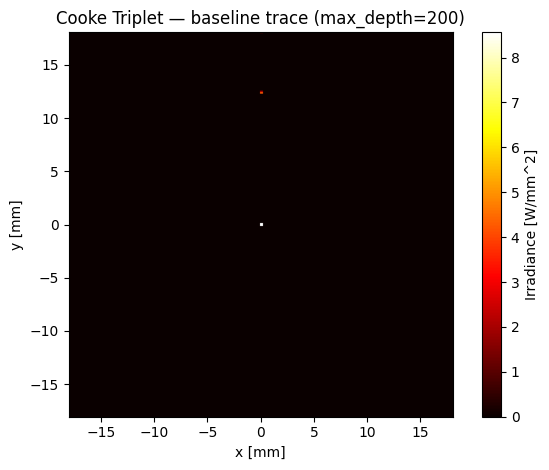

In [3]:
result_base = scene_triplet.trace(num_rays=100_000, max_depth=200, seed=42)
irr_base = result_base.detectors['D1']

print(f"Baseline flux on detector: {irr_base.total_flux:.5f} W")
print(f"Rays on detector         : {irr_base.num_rays_hit:,}")

fig = irr_base.plot(cmap='hot')
plt.title('Cooke Triplet — baseline trace (max_depth=200)')
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Limited-Bounce Comparison

Lowering `max_depth` restricts how many surface interactions each ray can
have. Rays exceeding the limit are killed without reaching the detector.
Here we compare a tight limit (few ghost paths possible) against the full trace:

Multi-bounce flux on detector : 1.62684 W
Rays on detector              : 108,456


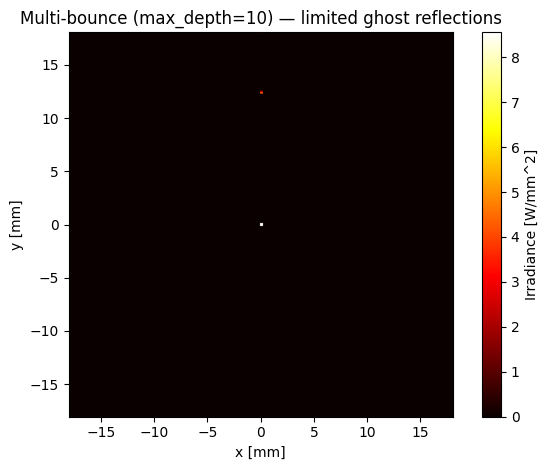

In [4]:
# Rebuild scene each trace (detectors accumulate across calls)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    scene_ghosts = sequential_to_nonsequential(
        CookeTriplet(),
        detector_pixels=(256, 256),
    )

result_ghosts = scene_ghosts.trace(
    num_rays=200_000,
    max_depth=10,
    min_flux_fraction=1e-8,  # track very faint rays
    seed=42,
)
irr_ghosts = result_ghosts.detectors['D1']

print(f"Multi-bounce flux on detector : {irr_ghosts.total_flux:.5f} W")
print(f"Rays on detector              : {irr_ghosts.num_rays_hit:,}")

fig = irr_ghosts.plot(cmap='hot')
plt.title('Multi-bounce (max_depth=10) — limited ghost reflections')
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Ghost Contribution as a Function of Bounces

Track how the detected flux changes as we allow more reflections:

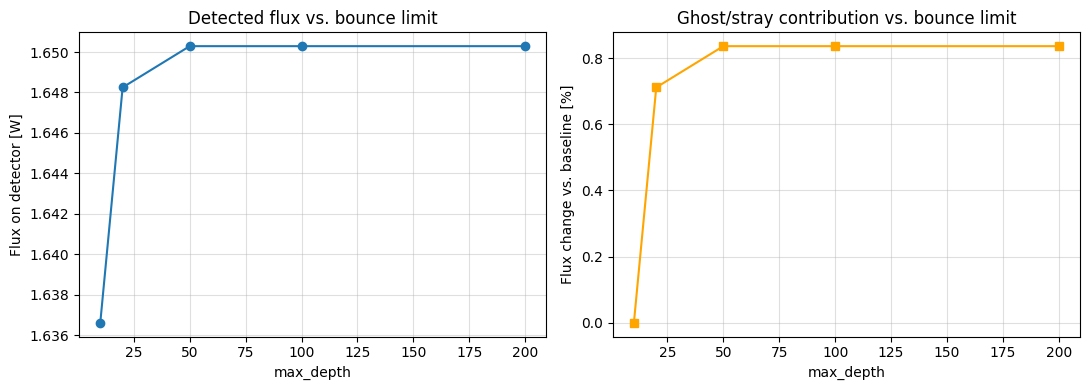

max_depth= 10: flux=1.63661 W  delta=+0.000%
max_depth= 20: flux=1.64825 W  delta=+0.711%
max_depth= 50: flux=1.65029 W  delta=+0.836%
max_depth=100: flux=1.65029 W  delta=+0.836%
max_depth=200: flux=1.65029 W  delta=+0.836%


In [5]:
bounce_levels = [10, 20, 50, 100, 200]
detected_fluxes = []

for max_b in bounce_levels:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sc = sequential_to_nonsequential(CookeTriplet(), detector_pixels=(128, 128))
    r = sc.trace(num_rays=50_000, max_depth=max_b, min_flux_fraction=1e-8, seed=42)
    detected_fluxes.append(r.detectors['D1'].total_flux)

# Compute ghost fraction relative to lowest-bounce baseline (guard against zero)
base = detected_fluxes[0] if detected_fluxes[0] > 1e-12 else max(detected_fluxes)
ghost_fractions = [
    (f - base) / base * 100
    for f in detected_fluxes
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(bounce_levels, detected_fluxes, 'o-')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Flux on detector [W]')
axes[0].set_title('Detected flux vs. bounce limit')
axes[0].grid(True, alpha=0.4)

axes[1].plot(bounce_levels, ghost_fractions, 's-', color='orange')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Flux change vs. baseline [%]')
axes[1].set_title('Ghost/stray contribution vs. bounce limit')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

for b, f, g in zip(bounce_levels, detected_fluxes, ghost_fractions):
    print(f"max_depth={b:>3}: flux={f:.5f} W  delta={g:+.3f}%")

## 5. Isolating the Ghost Contribution

Building a scene by hand gives full control over the bounce budget, and
comparing two bounce limits separates the direct image from the stray light:

- `max_depth = surfaces + 1` allows **only** the direct path.
- A larger limit additionally admits rays that reflected an even number of
  times inside the system, which is exactly what forms a ghost.

Subtracting the two irradiance maps leaves the ghost pattern on its own.


Direct path only (max_depth=5) : 0.66687 W (133,375 rays)
All paths (max_depth=16)       : 0.67190 W (134,379 rays)
Ghost contribution             : 0.00502 W (0.75% of the detected light)


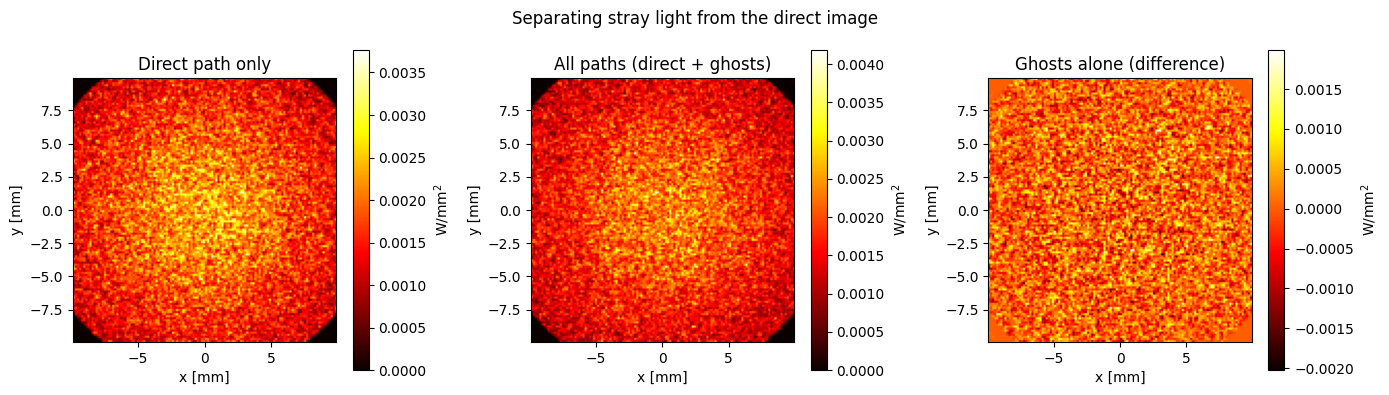

In [6]:
spec = Spectrum.monochromatic(0.55)


def build_stray_scene():
    """Two-element system: 4 refracting surfaces on the direct path."""
    sc = NSQScene()
    sc.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
    )
    sc.add_lens(
        'L1', CoordinateSystem(z=0),
        LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                   front_aperture_radius=12.5),
    )
    sc.add_lens(
        'L2', CoordinateSystem(z=40),
        LensConfig(r1=-80, r2=80, thickness=4, material='N-SF5',
                   front_aperture_radius=12.5),
    )
    sc.add_detector(
        'D', CoordinateSystem(z=120),
        IrradianceDetectorConfig(width=20, height=20,
                                 num_pixels_x=128, num_pixels_y=128),
    )
    return sc


# 4 refracting surfaces + 1 detector hit = 5 interactions for the direct path.
r_direct = build_stray_scene().trace(
    num_rays=200_000, max_depth=5, min_flux_fraction=1e-8, seed=42)
r_full = build_stray_scene().trace(
    num_rays=200_000, max_depth=16, min_flux_fraction=1e-8, seed=42)

i_direct = r_direct.detectors['D']
i_full = r_full.detectors['D']
ghost_flux = i_full.total_flux - i_direct.total_flux

print(f"Direct path only (max_depth=5) : {i_direct.total_flux:.5f} W "
      f"({i_direct.num_rays_hit:,} rays)")
print(f"All paths (max_depth=16)       : {i_full.total_flux:.5f} W "
      f"({i_full.num_rays_hit:,} rays)")
print(f"Ghost contribution             : {ghost_flux:.5f} W "
      f"({ghost_flux / i_full.total_flux * 100:.2f}% of the detected light)")

ghost_map = i_full.irradiance - i_direct.irradiance
extent = [i_full.x_coords[0], i_full.x_coords[-1],
          i_full.y_coords[0], i_full.y_coords[-1]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(
    axes,
    [i_direct.irradiance, i_full.irradiance, ghost_map],
    ['Direct path only', 'All paths (direct + ghosts)', 'Ghosts alone (difference)'],
):
    im = ax.imshow(data, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(title)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

plt.suptitle('Separating stray light from the direct image', fontsize=12)
plt.tight_layout()
plt.show()


## Summary

- `sequential_to_nonsequential(optic)` converts an `Optic` into an `NSQScene`
- The NSQ tracer applies **Fresnel splitting** at every uncoated interface, which
  is what produces ghosts; the sequential tracer transmits everything
- `max_depth` counts every interaction including the detector hit, so the direct
  path needs `surfaces + 1`. Anything beyond that admits ghost paths
- Tracing the same scene at two bounce limits and subtracting the irradiance maps
  isolates the stray-light pattern
- `min_flux_fraction` decides how far faint ghost rays are followed; lower it when
  chasing weak stray light
- Ghosts are suppressed in practice by AR coatings. Coating support is not in this
  release (`SurfaceConfig.coating` is reserved), so ghost levels here correspond to
  uncoated surfaces and are a worst case
